📊 Energy Crisis and Stock Price Dataset: 2021-2024¶
Welcome! This notebook introduces you to the Energy Crisis and Stock Price Dataset from 2021 to 2024. In this notebook, we will demonstrate how you can utilize the data to derive meaningful insights, visualize trends, and understand the impact of energy crises on the stock prices of major energy companies. 🌍📈💡

## 📥 1. Importing Libraries and Loading Data

In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import plotly.graph_objects as go



In [2]:
#Load datasets

xom = pd.read_csv("C:\Data Analyst Projects\Stock prediction\XOM_data.csv")
xom.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2021-01-04,41.450001,42.250000,41.000000,41.500000,35.163219,27764700
1,2021-01-05,41.840000,44.799999,41.830002,43.500000,36.857830,44035100
2,2021-01-06,44.410000,45.099998,43.700001,44.610001,37.798344,36484800
3,2021-01-07,45.000000,45.570000,44.529999,44.959999,38.094898,29528100
4,2021-01-08,45.200001,45.820000,44.950001,45.459999,38.518559,28628200


In [3]:
shell = pd.read_csv("C:\Data Analyst Projects\Stock prediction\SHEL_data.csv")
shell.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2021-01-04,36.250000,36.360001,35.494999,36.029999,31.140999,6794599
1,2021-01-05,37.189999,39.014999,37.115002,38.509998,33.284489,8518589
2,2021-01-06,39.910000,40.680000,39.564999,40.290001,34.822952,9180332
3,2021-01-07,40.000000,40.625000,39.744999,40.340000,34.866161,4829303
4,2021-01-08,40.360001,40.419998,39.770000,40.240002,34.779736,5546750


In [4]:
bp = pd.read_csv("C:\Data Analyst Projects\Stock prediction\BP_data.csv")
bp.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2021-01-04,21.090000,21.129999,20.549999,20.830000,17.184427,14485100
1,2021-01-05,21.430000,22.780001,21.370001,22.379999,18.463150,25447500
2,2021-01-06,23.370001,23.860001,22.940001,23.410000,19.312887,25221400
3,2021-01-07,23.719999,24.150000,23.500000,23.910000,19.725380,16470700
4,2021-01-08,24.170000,24.490000,23.990000,24.400000,20.129620,20189600


In [5]:
print("\nsummary for XOM dataset")
print(xom.describe())

print("\nsummary for SHELL dataset")
print(shell.describe())

print("\nsummary for BP dataset")
print(bp.describe())


summary for XOM dataset
             Open        High         Low       Close   Adj Close  \
count  977.000000  977.000000  977.000000  977.000000  977.000000   
mean    92.278618   93.319642   91.301505   92.336315   86.770530   
std     23.157683   23.293578   22.973333   23.136443   24.600429   
min     41.450001   42.250000   41.000000   41.500000   35.163219   
25%     64.610001   65.330002   64.180000   64.519997   57.733021   
50%    102.000000  103.089996  100.910004  102.059998   97.441528   
75%    111.639999  113.089996  110.610001  111.610001  106.250908   
max    125.250000  126.339996  124.860001  125.370003  124.348221   

             Volume  
count  9.770000e+02  
mean   2.090369e+07  
std    8.748485e+06  
min    7.136000e+06  
25%    1.487760e+07  
50%    1.875670e+07  
75%    2.441240e+07  
max    8.443940e+07  

summary for SHELL dataset
             Open        High         Low       Close   Adj Close  \
count  977.000000  977.000000  977.000000  977.000000  977.

In [6]:
#Check mising value in all 3 datasets


print("\nMissing Values in (XOM):")
print(xom.isnull().sum())

print("\nMissing Values in Shell:")
print(shell.isnull().sum())

print("\nMissing Values in BP (BP):")
print(bp.isnull().sum())


Missing Values in (XOM):
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Missing Values in Shell:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Missing Values in BP (BP):
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [7]:
# Convert 'Date' to datetime formate for ploting

xom['Date'] = pd.to_datetime(xom['Date'])
shell['Date'] = pd.to_datetime(shell['Date'])
bp['Date'] = pd.to_datetime(bp['Date'])

In [8]:
# Setting Date as index for easier plotting

xom.set_index('Date', inplace=True)

shell.set_index('Date', inplace=True)

bp.set_index('Date', inplace=True)

In [9]:
xom.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2021-01-04,41.450001,42.250000,41.000000,41.500000,35.163219,27764700
2021-01-05,41.840000,44.799999,41.830002,43.500000,36.857830,44035100
2021-01-06,44.410000,45.099998,43.700001,44.610001,37.798344,36484800
2021-01-07,45.000000,45.570000,44.529999,44.959999,38.094898,29528100
2021-01-08,45.200001,45.820000,44.950001,45.459999,38.518559,28628200


### ⏱️ 2 Time series - stock prices over time

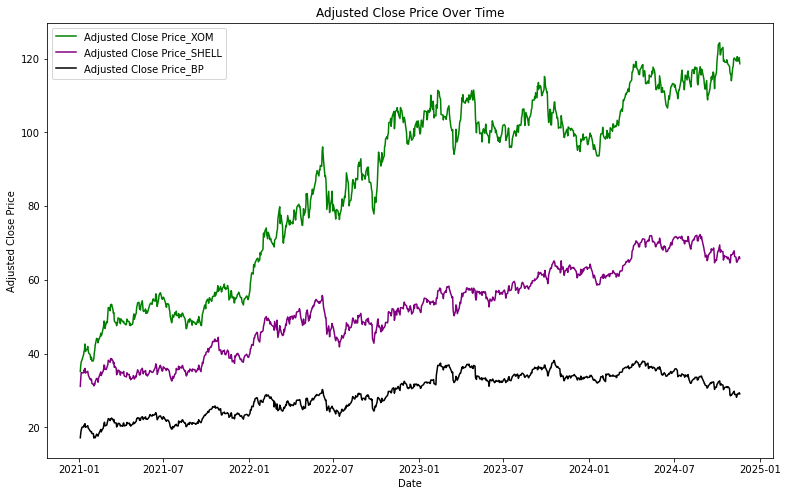

In [10]:
plt.figure(figsize=(13, 8))
sns.lineplot(data=xom, x=xom.index, y='Adj Close', label='Adjusted Close Price_XOM', color = 'green')
sns.lineplot(data=shell, x=shell.index, y='Adj Close', label='Adjusted Close Price_SHELL', color = 'purple')
sns.lineplot(data=bp, x=bp.index, y='Adj Close', label='Adjusted Close Price_BP', color = 'black')
plt.title('Adjusted Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price')
plt.show()

### 📌 3 Total volume per company

In [11]:
# Sum the total volume for each company

total_xom_vol = xom['Volume'].sum()
total_shell_vol = shell['Volume'].sum()
total_bp_vol = bp['Volume'].sum()

In [12]:
# Create a dictionary

total_volumes = {
    'XOM': total_xom_vol,
    'Shell': total_shell_vol,
    'BP': total_bp_vol
}

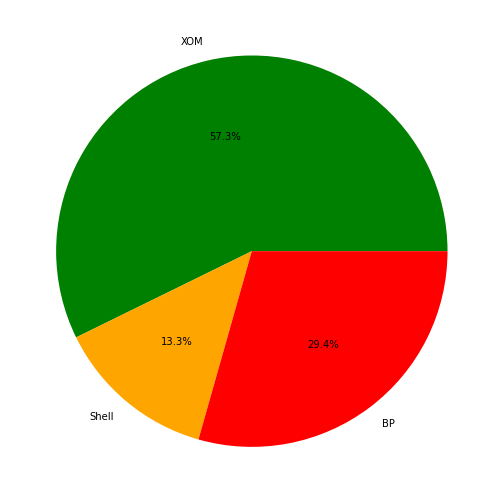

In [13]:
# Plotting the pie chart
plt.figure(figsize=(9, 9))
plt.pie(total_volumes.values(), labels=total_volumes.keys(), autopct='%1.1f%%', colors=['green', 'orange','red']);

### ⛓️ 4 Correlation Analysis

In [14]:
# Merge the DataFrames(all three files) on the Date index
merged_data = pd.merge(xom[['Adj Close']], shell[['Adj Close']], left_index=True, right_index=True, suffixes=('_XOM', '_SHELL'))
merged_data = pd.merge(merged_data, bp[['Adj Close']], left_index=True, right_index=True)
merged_data.rename(columns={'Adj Close': 'Adj Close_BP'}, inplace=True)

correlation_matrix = merged_data.corr()

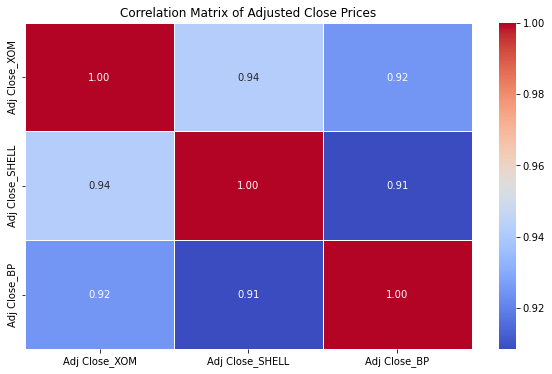

In [15]:
plt.figure(figsize = (10,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Adjusted Close Prices')
plt.show()

#XOM and Shell have a very strong positive correlation (0.95).
#XOM and BP have a slightly lower but still strong correlation (0.93).
#Shell and BP are also positively correlated (0.90).

In [16]:
# Calculate daily returns (percentage change)

xom['daily_return'] = xom['Adj Close'].pct_change()
shell['daily_return'] = shell['Adj Close'].pct_change()
bp['daily_return'] = bp['Adj Close'].pct_change()

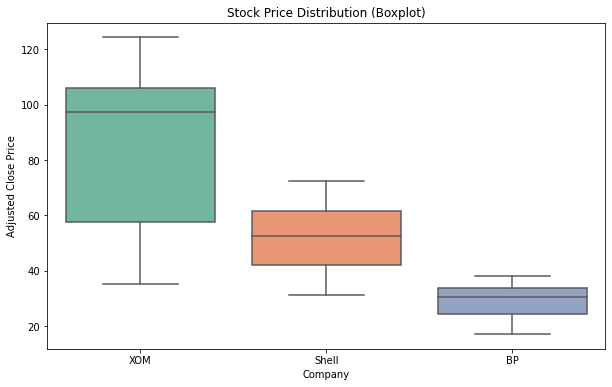

In [17]:
# Create a boxplot for adjusted close prices for each stock

plt.figure(figsize=(10, 6))

sns.boxplot(x='variable', y='value', data=pd.melt(pd.DataFrame({
    'XOM': xom['Adj Close'],
    'Shell': shell['Adj Close'],
    'BP': bp['Adj Close']
})), palette="Set2")

plt.title('Stock Price Distribution (Boxplot)')
plt.xlabel('Company')
plt.ylabel('Adjusted Close Price')
plt.show()


In [47]:
# Plot candlestick chart for XOM

fig = go.Figure(data=[go.Candlestick(x=xom.index,
                open=xom['Open'],
                high=xom['High'],
                low=xom['Low'],
                close=xom['Adj Close'],
                name='XOM')])

# Adjust layout for size and appearance
fig.update_layout(
    title='XOM Stock Price Candlestick Chart (High and Low)',
    xaxis_title='Date',
    yaxis_title='Price',
    xaxis_rangeslider_visible=False,
    width=600,  # Adjust width here
    height=500,  # Adjust height here
    margin=dict(l=50, r=50, t=50, b=50)  # Adjust margins for spacing
)

fig.show()

#### Merge all files into one DataFrame

In [19]:
merge_all = pd.merge(xom, shell, how = 'outer', on ='Date', suffixes= ('_xom', '_shell'))
merge_all = pd.merge(merge_all, bp, how = 'outer', on ='Date', suffixes= ('_shell', '_bp'))

print(merge_all.head())

             Open_xom   High_xom    Low_xom  Close_xom  Adj Close_xom  \
Date                                                                    
2021-01-04  41.450001  42.250000  41.000000  41.500000      35.163219   
2021-01-05  41.840000  44.799999  41.830002  43.500000      36.857830   
2021-01-06  44.410000  45.099998  43.700001  44.610001      37.798344   
2021-01-07  45.000000  45.570000  44.529999  44.959999      38.094898   
2021-01-08  45.200001  45.820000  44.950001  45.459999      38.518559   

            Volume_xom  daily_return_xom  Open_shell  High_shell  Low_shell  \
Date                                                                          
2021-01-04    27764700               NaN   36.250000   36.360001  35.494999   
2021-01-05    44035100          0.048193   37.189999   39.014999  37.115002   
2021-01-06    36484800          0.025517   39.910000   40.680000  39.564999   
2021-01-07    29528100          0.007846   40.000000   40.625000  39.744999   
2021-01-08    

### 🛠️5 Feature Engineering

In [20]:
merge_all['prev_close'] = merge_all['Close'].shift(1)  # Lag feature
merge_all['rolling_close_7'] = merge_all['Close'].rolling(window=7).mean()  # 7-day moving average
merge_all['rolling_close_30'] = merge_all['Close'].rolling(window=30).mean()  # 30-day moving average

In [21]:
# Drop NaN values after feature creation

merge_all = merge_all.dropna()
merge_all.isnull().sum()

Open_xom              0
High_xom              0
Low_xom               0
Close_xom             0
Adj Close_xom         0
Volume_xom            0
daily_return_xom      0
Open_shell            0
High_shell            0
Low_shell             0
Close_shell           0
Adj Close_shell       0
Volume_shell          0
daily_return_shell    0
Open                  0
High                  0
Low                   0
Close                 0
Adj Close             0
Volume                0
daily_return          0
prev_close            0
rolling_close_7       0
rolling_close_30      0
dtype: int64

### 🤖 6 Model Training and Evaluation

In [22]:
# define features and target
features = ['prev_close', 'rolling_close_7', 'rolling_close_30']
X = merge_all[features]
y = merge_all['Close']

#Spliitng data inot 80% train and 20% test formate
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [26]:
# Train model

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [27]:
# Predictions
y_pred = model.predict(X_test)

In [30]:
# Evaluate model
MAE = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {MAE}")

Mean Absolute Error (MAE): 0.48305371445103673


### 📉 7 Model Visualizations

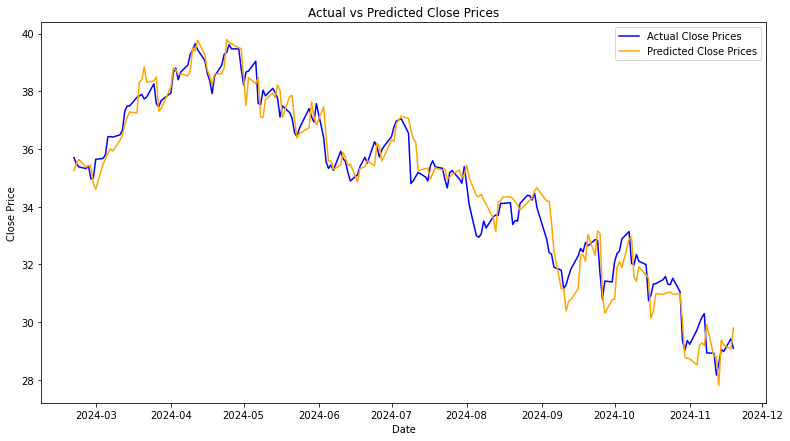

In [45]:
# Visualize Actual vs Predicted

plt.figure(figsize=(13, 7))
plt.plot(y_test.index, y_test, label='Actual Close Prices', color='blue', linestyle='solid')
plt.plot(y_test.index, y_pred, label='Predicted Close Prices', color='orange', linestyle='solid')
plt.title('Actual vs Predicted Close Prices')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()